In [1]:
# Making sure filepath runs smoothly
import sys
import os

print(sys.executable) 

env_root = sys.prefix

env_bin = os.path.join(env_root, "bin")
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled
env_r_lib = os.path.join(env_root, "lib", "R", "library")
ro.r(f'.libPaths("{env_r_lib}")')

print("R libPaths now:")
print(ro.r(".libPaths()"))
print("phyloseq installed?", isinstalled("phyloseq"))

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/bin/python
R libPaths now:
[1] "/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/R/library"

phyloseq installed? True


In [2]:
# imports for data analysis

# data analysis
import pandas as pd
import numpy as np
import json

# qiime and related
import qiime2
from qiime2 import Metadata, Artifact
import biom

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, roc_auc_score, f1_score

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression

In [3]:
# Loading in features from absolute quantitative feature table
# This is just to see what columns are present vs. the joined metadata
artifact = qiime2.Artifact.load("/ddn_scratch/k5zhao/data/metaG-absquant-clean.qza")
df = artifact.view(pd.DataFrame)
df.head()

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/qiime2/core/cache.py:476: UserWarning: Your temporary cache was found to be in an inconsistent state. It has been recreated.
  warnings.warn(
/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/q2_assembly/_utils.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,G000006865,G000006925,G000007265,G000007325,G000007465,G000007525,G000007645,G000007785,G000008345,G000008865,...,G902363725,G902363825,G902364485,G902373415,G902377395,G902385285,G902387315,G902406265,G902501965,G902765685
223473.15288.MMC.23900510922.359188424,1267.402606,3072.008840,812.647360,255.353260,0.000000,2.456617e+02,0.0,986.006620,0.00000,6799.159198,...,104982.468752,152477.967040,88960.105674,726.754773,4448.535379,3.729751e+06,4.891244e+05,0.000000,684.542294,0.000000
223473.15288.MMC.23900725620.359188362,27387.626839,1992.279409,172.828240,0.000000,0.000000,3.549257e+02,0.0,3535.161616,0.00000,4452.727077,...,123465.866303,340471.880084,194806.248788,2637.623757,3886.225016,9.336932e+05,1.199756e+06,4110.195897,2987.328552,0.000000
223473.15288.MMC.23900511370.359250503,970.372929,13352.856644,987.812532,78.486140,83.951996,4.408847e+02,0.0,827.132101,66.66033,22103.351691,...,132397.796944,50022.912167,12429.766939,0.000000,717.474743,4.394429e+05,9.131579e+03,72.915833,2295.087154,0.000000
223473.15288.MMC.23900510917.359250951,0.000000,4523.616914,0.000000,4669.933571,0.000000,3.525867e+05,0.0,653.144694,0.00000,13955.827110,...,137060.956445,78885.127944,157107.515302,1099.751032,2938.273700,1.571641e+06,4.521045e+05,21931.639297,3487.852026,0.000000
223473.15288.MMC.23900511036.359188313,2911.966294,23364.182340,298.711590,0.000000,150.392006,6.132011e+06,0.0,2545.082052,0.00000,50608.469202,...,192679.633104,63432.826904,177625.624122,153.210106,6042.208555,5.427096e+05,4.772996e+05,275.695047,144.311123,120.002037


In [23]:
df.columns[:1148]

Index(['G000006865', 'G000006925', 'G000007265', 'G000007325', 'G000007465',
       'G000007525', 'G000007645', 'G000007785', 'G000008345', 'G000008865',
       ...
       'G902363725', 'G902363825', 'G902364485', 'G902373415', 'G902377395',
       'G902385285', 'G902387315', 'G902406265', 'G902501965', 'G902765685'],
      dtype='object', length=1148)

In [12]:
df.index

Index(['223473.15288.MMC.23900510922.359188424',
       '223473.15288.MMC.23900725620.359188362',
       '223473.15288.MMC.23900511370.359250503',
       '223473.15288.MMC.23900510917.359250951',
       '223473.15288.MMC.23900511036.359188313',
       '223473.15288.MMC.23900725634.359188448',
       '223473.15288.MMC.23900511015.359250535',
       '223473.15288.MMC.23900511524.359188365',
       '223473.15288.MMC.23900511191.359250978',
       '223473.15288.MMC.23900510566.359250536',
       ...
       '226544.15288.MMC.24900932496.364416125',
       '226544.15288.MMC.24901045371.363325545',
       '226544.15288.MMC.24901044947.363358290',
       '226544.15288.MMC.24900942532.363284789',
       '226544.15288.MMC.24901045975.363325512',
       '226544.15288.MMC.24901044735.363325078',
       '226544.15288.MMC.24901044643.363358297',
       '226544.15288.MMC.24901046525.363358299',
       '226544.15288.MMC.23900766253.363358319',
       '226544.15288.MMC.24900932912.363284781'],
      dt

In [5]:
# Loading in absolute quant metadata
# This is just so I can better see the columns
metadata = pd.read_csv('/ddn_scratch/k5zhao/data/metadata_absquant_clean.tsv', sep='\t')
metadata.head()

,#SampleID,runid,lane,run_center,total_rna_concentration_ng_ul,run_date,center_project_name,i5_index_id,index,fraction_passing_quality_filter,...,qiita_artifact_id,qiita_prep_deprecated,original_SampleID,qiita_study_title,qiita_study_alias,qiita_owner,qiita_principal_investigator,extracted_gdna_concentration_ng_ul,mass_syndna_input_ng,syndna_pool_number
0,223473.15288.MMC.23900510922.359188424,240710_LH00444_0150_A22CYN7LT4,8,IGM,unknown,2024-07-10,NPH,iTru5_14_F,ACACGGTT,0.714227,...,223473,False,15288.MMC.23900510922.359188424,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,1.607,0.250089,1
1,223473.15288.MMC.23900725620.359188362,240710_LH00444_0150_A22CYN7LT4,8,IGM,unknown,2024-07-10,NPH,iTru5_108_F,CATGAGGA,0.820310,...,223473,False,15288.MMC.23900725620.359188362,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,5.374,0.249891,1
2,223473.15288.MMC.23900511370.359250503,240710_LH00444_0150_A22CYN7LT4,8,IGM,unknown,2024-07-10,NPH,iTru5_05_E,TGACGCAT,0.938472,...,223473,False,15288.MMC.23900511370.359250503,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,1.857,0.249999,1
3,223473.15288.MMC.23900510917.359250951,240710_LH00444_0150_A22CYN7LT4,8,IGM,unknown,2024-07-10,NPH,iTru5_114_D,ATTGCGTG,0.584370,...,223473,False,15288.MMC.23900510917.359250951,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,10.152,0.249993,1
4,223473.15288.MMC.23900511036.359188313,240710_LH00444_0150_A22CYN7LT4,8,IGM,unknown,2024-07-10,NPH,iTru5_108_E,CACCACTA,0.862706,...,223473,False,15288.MMC.23900511036.359188313,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,3.716,0.249901,1


# RandomForestClassifier
To start our comparison, we wanted to compare the performance of absolute quant data vs. relative abundance data on predicting age as a category, e.g. based on given microbiota, is a patient 20-30 years old?

In [8]:
# Loading in absolute quant data for train/test/validation split
# Should run log transformation
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv')
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv')

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv')
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv')

/tmp/ipykernel_6675/2900004183.py:3: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
/tmp/ipykernel_6675/2900004183.py:7: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')


In [6]:
abs_train.head()

,original_SampleID,G000006865,G000006925,G000007265,G000007325,G000007465,G000007525,G000007645,G000007785,G000008345,...,study,qiita_artifact_id,qiita_prep_deprecated,qiita_study_title,qiita_study_alias,qiita_owner,qiita_principal_investigator,extracted_gdna_concentration_ng_ul,mass_syndna_input_ng,syndna_pool_number
0,15288.MMC.24900842617.363278969,0.000000,930408.164633,2116.435847,7.101059e+03,1043.519702,5.582126e+03,0.0,8994.272126,0.000000,...,NPH Module 1,223480,False,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,16.983,0.250075,1
1,15288.MMC.24900843266.3547958130,15160.832351,8013.263184,781.871436,1.597121e+02,170.834615,6.475987e+03,0.0,2636.898537,268.079531,...,NPH Module 1,223481,False,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,1.583,0.249876,1
2,15288.MMC.24901045038.367085748,542621.297518,34127.752542,6778.709996,1.911422e+06,0.000000,2.340431e+08,0.0,92448.249026,5719.651484,...,NPH Module 1,225262,False,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,30.140,0.249546,1
3,15288.MMC.23900510733.364174995,288979.358841,153507.561461,14383.361260,0.000000e+00,5720.236296,5.144841e+03,0.0,85400.277620,0.000000,...,NPH Module 1,223481,False,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,6.895,0.249705,1
4,15288.MMC.23900510735.359188373,0.000000,14629.460388,1349.651497,0.000000e+00,0.000000,8.429230e+05,0.0,7407.571749,0.000000,...,NPH Module 1,223473,False,Nutrition for Precision Health,NPH,MacKenzie Bryant,Rob Knight,10.423,0.250152,1


In [10]:
abs_train.columns[:1148]

Index(['original_SampleID', 'G000006865', 'G000006925', 'G000007265',
       'G000007325', 'G000007465', 'G000007525', 'G000007645', 'G000007785',
       'G000008345',
       ...
       'G902363685', 'G902363725', 'G902363825', 'G902364485', 'G902373415',
       'G902377395', 'G902385285', 'G902387315', 'G902406265', 'G902501965'],
      dtype='object', length=1148)

In [24]:
# Creating X and Y features
# Using American Gut Microbiome Project age cutoffs, remove outliers
abs_train = abs_train.loc[(abs_train["age"] >= 20) & (abs_train["age"] <= 69)]
abs_test = abs_test.loc[(abs_test["age"] >= 20) & (abs_test["age"] <= 69)]
abs_val = abs_val.loc[(abs_val["age"] >= 20) & (abs_val["age"] <= 69)]

rel_train = rel_train.loc[(rel_train["age"] >= 20) & (rel_train["age"] <= 69)]
rel_test = rel_test.loc[(rel_test["age"] >= 20) & (rel_test["age"] <= 69)]
rel_val = rel_val.loc[(rel_val["age"] >= 20) & (rel_val["age"] <= 69)]

# Absolute quant data
abs_X_train = abs_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_train[rel_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']

In [25]:
# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

In [28]:
# Testing classification on bins of 10 years first
bins = [20, 30, 40, 50, 60, 70]

abs_Y_class_train = pd.cut(
    abs_Y_train,
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_Y_class_test=pd.cut(
    abs_Y_test,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

abs_Y_class_val=pd.cut(
    abs_Y_val,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_train = pd.cut(
    rel_Y_train,
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_test=pd.cut(
    rel_Y_test,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_val=pd.cut(
    rel_Y_val,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

## Absolute Quant RandomForestClassifier

In [35]:
# Training the model on absolute quant data
# Treating the classes as more balanced to see if it improves accuracy
abs_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

abs_rf.fit(abs_X_train_log, abs_Y_class_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [36]:
# Evaluating the model
val_preds = abs_rf.predict(abs_X_val_log)

print("Validation accuracy:", accuracy_score(abs_Y_class_val, val_preds))

Validation accuracy: 0.35634328358208955


In [37]:
cm = confusion_matrix(abs_Y_class_val, val_preds)
cm

array([[14,  9,  5, 24, 20],
       [ 3, 10,  4, 40, 30],
       [ 1,  1, 10, 52, 36],
       [ 0,  3,  5, 58, 41],
       [ 2,  1,  5, 63, 99]])

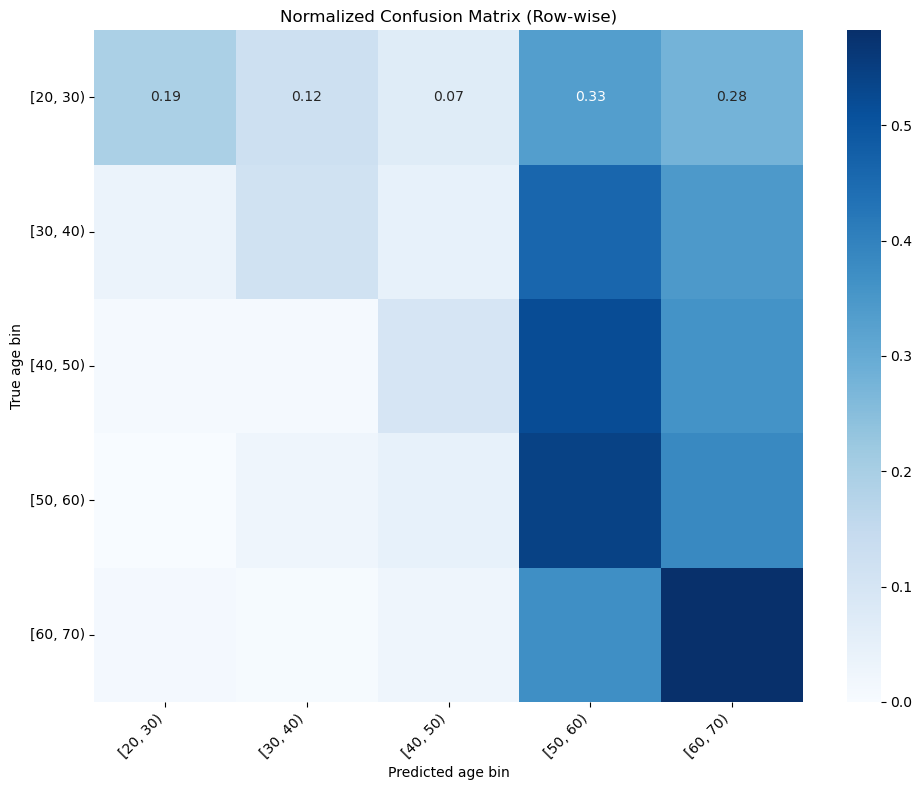

In [38]:
labels = abs_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted age bin")
plt.ylabel("True age bin")
plt.title("Normalized Confusion Matrix (Row-wise)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

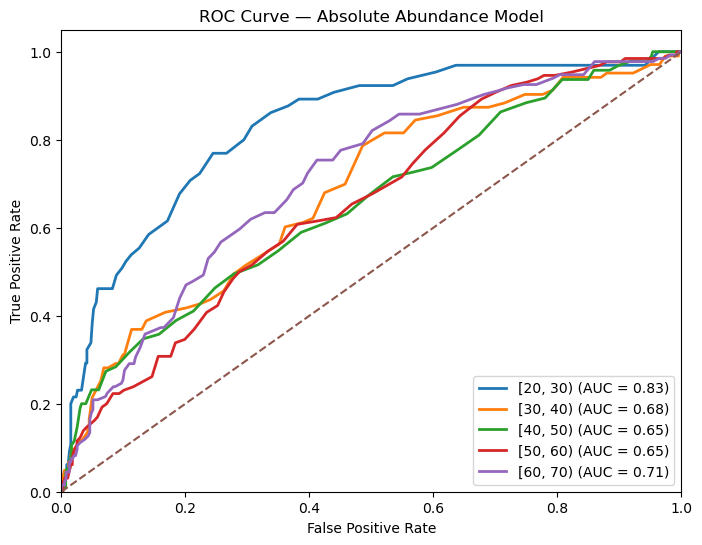

In [43]:
# Plotting the ROC Curves
abs_y_pred_prob = abs_rf.predict_proba(abs_X_test_log)
abs_Y_test_cat = abs_Y_class_test.astype("category")
abs_Y_test_codes = abs_Y_test_cat.cat.codes

classes = list(range(len(abs_Y_test_cat.cat.categories)))

abs_y_test_bin = label_binarize(abs_Y_test_codes, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(
        abs_y_test_bin[:, i],
        abs_y_pred_prob[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))

bin_labels = abs_Y_test_cat.cat.categories

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{bin_labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Absolute Abundance Model")
plt.legend(loc="lower right")
plt.show()

In [45]:
# Macro AUC
macro_auc = roc_auc_score(
    abs_y_test_bin,
    abs_y_pred_prob,
    average="macro"
)

print("Macro-average AUC:", macro_auc)

Macro-average AUC: 0.7050512998487442


In [46]:
for i in range(len(roc_auc)):
    print(bin_labels[i], roc_auc[i])

[20, 30) 0.8283882783882783
[30, 40) 0.6817755083348598
[40, 50) 0.6521442495126706
[50, 60) 0.6531292385196666
[60, 70) 0.7098192244882457


## Relative Quant RandomForestClassifier

In [59]:
# Training the model on absolute quant data
# Treating the classes as more balanced to see if it improves accuracy
rel_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rel_rf.fit(rel_X_train_log, rel_Y_class_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [48]:
# Evaluating the model
val_preds = rel_rf.predict(rel_X_val_log)

print("Validation accuracy:", accuracy_score(rel_Y_class_val, val_preds))

Validation accuracy: 0.40671641791044777


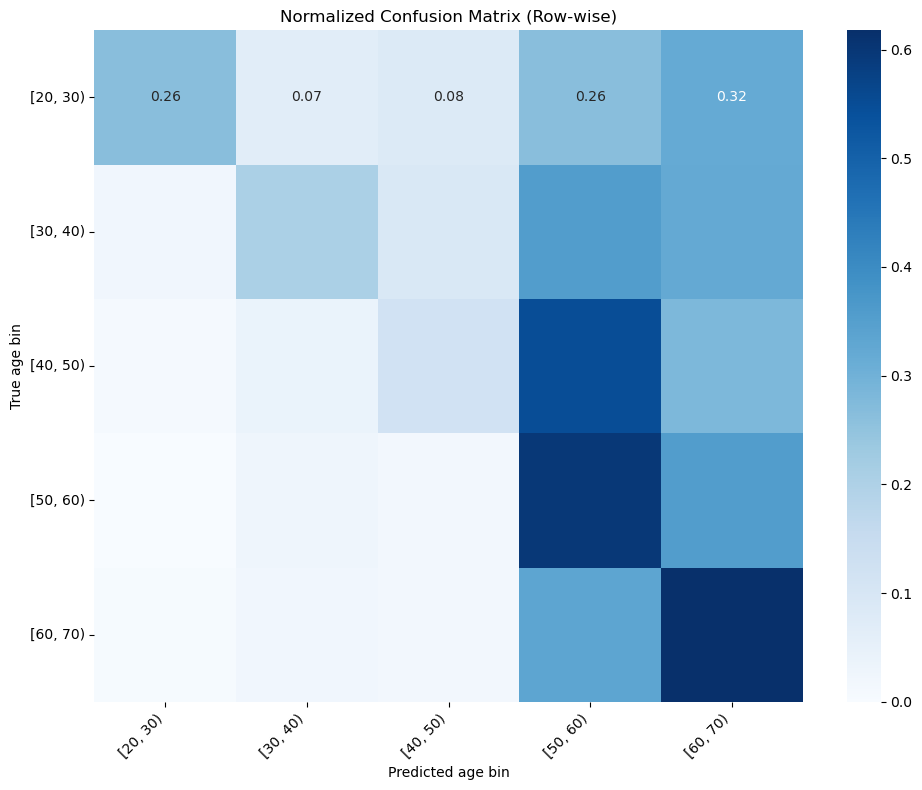

In [49]:
cm = confusion_matrix(rel_Y_class_val, val_preds)
labels = rel_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted age bin")
plt.ylabel("True age bin")
plt.title("Normalized Confusion Matrix (Row-wise)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

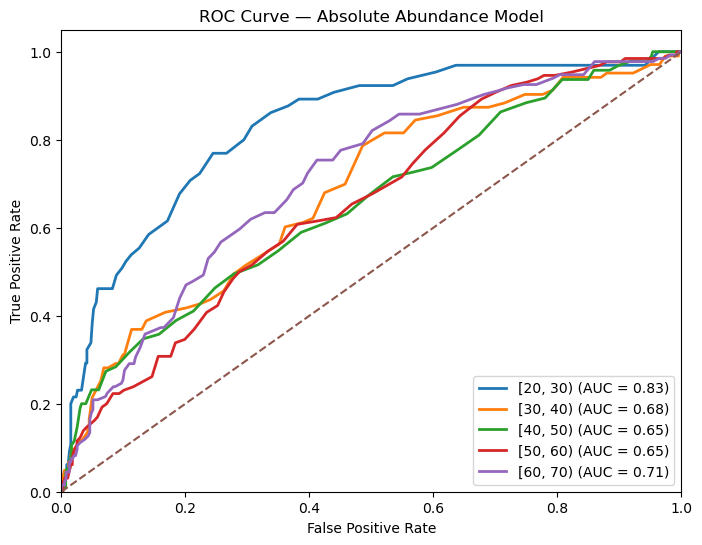

In [51]:
# Plotting the ROC Curves
rel_y_pred_prob = rel_rf.predict_proba(rel_X_test_log)
rel_Y_test_cat = rel_Y_class_test.astype("category")
rel_Y_test_codes = rel_Y_test_cat.cat.codes

classes = list(range(len(rel_Y_test_cat.cat.categories)))

rel_y_test_bin = label_binarize(rel_Y_test_codes, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(
        abs_y_test_bin[:, i],
        abs_y_pred_prob[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))

bin_labels = rel_Y_test_cat.cat.categories

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{bin_labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Absolute Abundance Model")
plt.legend(loc="lower right")
plt.show()

In [52]:
# Macro AUC
macro_auc = roc_auc_score(
    rel_y_test_bin,
    rel_y_pred_prob,
    average="macro"
)

print("Macro-average AUC:", macro_auc)

Macro-average AUC: 0.716887138307417


In [53]:
for i in range(len(roc_auc)):
    print(bin_labels[i], roc_auc[i])

[20, 30) 0.8283882783882783
[30, 40) 0.6817755083348598
[40, 50) 0.6521442495126706
[50, 60) 0.6531292385196666
[60, 70) 0.7098192244882457


## Tuning: Changing bin sizes and adding classificatiers for outliers

In [54]:
# Loading in absolute quant data for train/test/validation split
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv')
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv')

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv')
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv')

/tmp/ipykernel_6675/3869585525.py:2: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
/tmp/ipykernel_6675/3869585525.py:6: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')


In [55]:
# Absolute quant data
abs_X_train = abs_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_train[rel_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']

In [56]:
# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

In [57]:
# Rebinning
bins = [0, 20, 35, 50, 65, 80, np.inf]

abs_Y_class_train = pd.cut(
    abs_Y_train,
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_Y_class_test=pd.cut(
    abs_Y_test,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

abs_Y_class_val=pd.cut(
    abs_Y_val,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_train = pd.cut(
    rel_Y_train,
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_test=pd.cut(
    rel_Y_test,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_val=pd.cut(
    rel_Y_val,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

## Re-Tuned Absolute Quant RandomForestClassifier

In [70]:
# Training the model on absolute quant data
# Treating the classes as more balanced to see if it improves accuracy
abs_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

abs_rf.fit(abs_X_train_log, abs_Y_class_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [71]:
# Evaluating the model
val_preds = abs_rf.predict(abs_X_val_log)

print("Validation accuracy:", accuracy_score(abs_Y_class_val, val_preds))

Validation accuracy: 0.36577708006279436


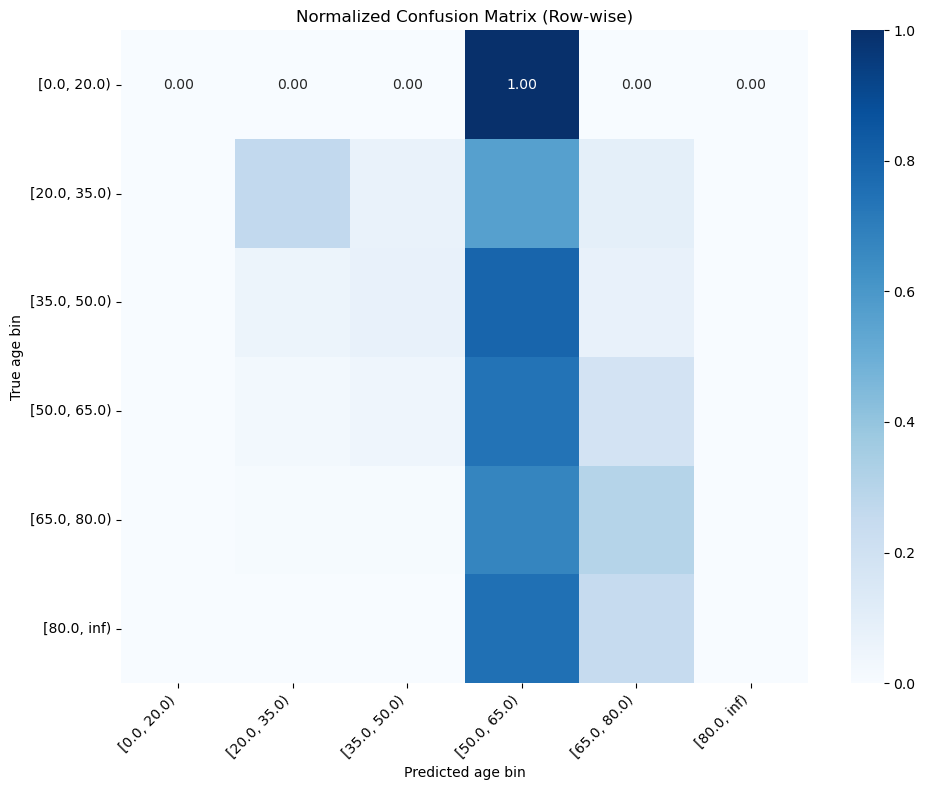

In [72]:
cm = confusion_matrix(abs_Y_class_val, val_preds)
labels = abs_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted age bin")
plt.ylabel("True age bin")
plt.title("Normalized Confusion Matrix (Row-wise)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

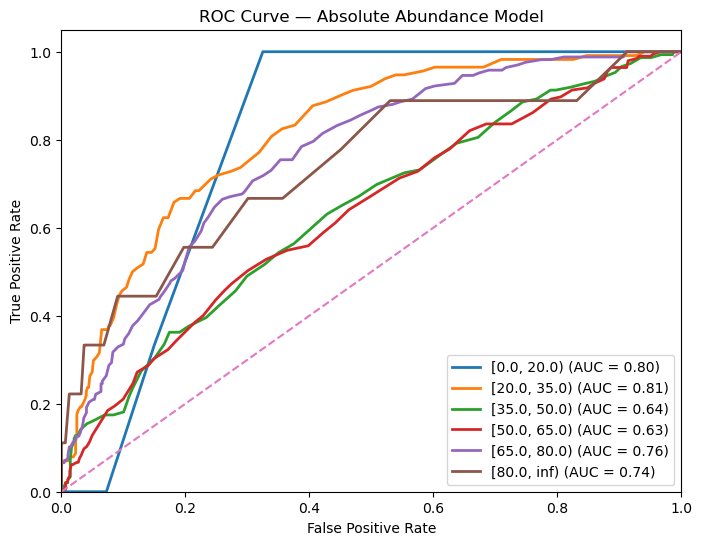

In [73]:
# Plotting the ROC Curves
abs_y_pred_prob = abs_rf.predict_proba(abs_X_test_log)
abs_Y_test_cat = abs_Y_class_test.astype("category")
abs_Y_test_codes = abs_Y_test_cat.cat.codes

classes = list(range(len(abs_Y_test_cat.cat.categories)))

abs_y_test_bin = label_binarize(abs_Y_test_codes, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(
        abs_y_test_bin[:, i],
        abs_y_pred_prob[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))

bin_labels = abs_Y_test_cat.cat.categories

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{bin_labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Absolute Abundance Model")
plt.legend(loc="lower right")
plt.show()

In [74]:
# Macro AUC
macro_auc = roc_auc_score(
    abs_y_test_bin,
    abs_y_pred_prob,
    average="macro"
)

print("Macro-average AUC:", macro_auc)

Macro-average AUC: 0.7315268325229319


In [75]:
for i in range(len(roc_auc)):
    print(bin_labels[i], roc_auc[i])

[0.0, 20.0) 0.8046792849631966
[20.0, 35.0) 0.8134497333199155
[35.0, 50.0) 0.636579931785675
[50.0, 65.0) 0.6304559693699965
[65.0, 80.0) 0.7636386800866353
[80.0, inf) 0.7403573956121727


In [76]:
## Re-tuned Relative Quant Classifier

In [77]:
# Training the model on absolute quant data
# Treating the classes as more balanced to see if it improves accuracy
rel_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rel_rf.fit(rel_X_train_log, rel_Y_class_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [78]:
# Evaluating the model
val_preds = rel_rf.predict(rel_X_val_log)

print("Validation accuracy:", accuracy_score(rel_Y_class_val, val_preds))

Validation accuracy: 0.41287284144427


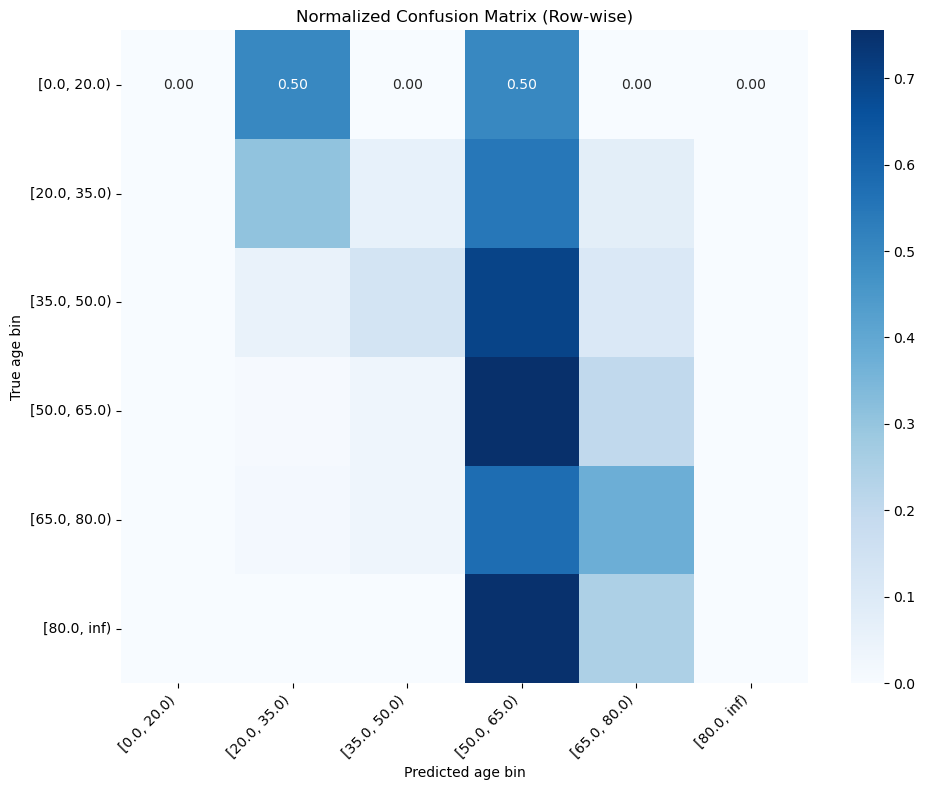

In [79]:
cm = confusion_matrix(rel_Y_class_val, val_preds)
labels = rel_rf.classes_
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted age bin")
plt.ylabel("True age bin")
plt.title("Normalized Confusion Matrix (Row-wise)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

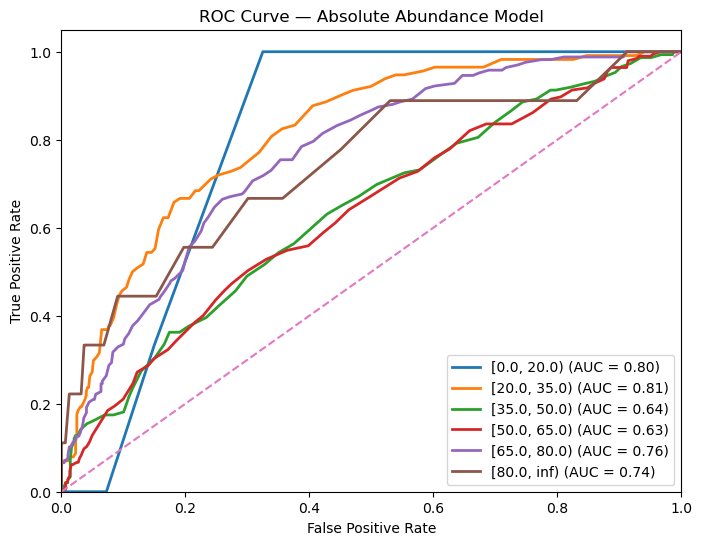

In [80]:
# Plotting the ROC Curves
rel_y_pred_prob = rel_rf.predict_proba(rel_X_test_log)
rel_Y_test_cat = rel_Y_class_test.astype("category")
rel_Y_test_codes = rel_Y_test_cat.cat.codes

classes = list(range(len(rel_Y_test_cat.cat.categories)))

rel_y_test_bin = label_binarize(rel_Y_test_codes, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(
        abs_y_test_bin[:, i],
        abs_y_pred_prob[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))

bin_labels = rel_Y_test_cat.cat.categories

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{bin_labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Absolute Abundance Model")
plt.legend(loc="lower right")
plt.show()

In [81]:
# Macro AUC
macro_auc = roc_auc_score(
    rel_y_test_bin,
    rel_y_pred_prob,
    average="macro"
)

print("Macro-average AUC:", macro_auc)

Macro-average AUC: 0.6993454083280116


In [82]:
for i in range(len(roc_auc)):
    print(bin_labels[i], roc_auc[i])

[0.0, 20.0) 0.8046792849631966
[20.0, 35.0) 0.8134497333199155
[35.0, 50.0) 0.636579931785675
[50.0, 65.0) 0.6304559693699965
[65.0, 80.0) 0.7636386800866353
[80.0, inf) 0.7403573956121727


## Final performance evaluation

In [3]:
# Loading in absolute quant data for train/test/validation split
# Should run log transformation
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv')
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv')

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv')
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv')

abs_train = pd.concat([abs_train, abs_val])
rel_train = pd.concat([rel_train, rel_val])

/tmp/ipykernel_58289/2770816207.py:3: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
/tmp/ipykernel_58289/2770816207.py:7: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')


In [4]:
# Absolute quant data
abs_X_train = abs_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

# Relative abundance data
rel_X_train = rel_train[rel_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

In [5]:
# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

In [6]:
# Rebinning
bins = [0, 20, 35, 50, 65, 80, np.inf]

abs_Y_class_train = pd.cut(
    abs_Y_train,
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_Y_class_test=pd.cut(
    abs_Y_test,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_train = pd.cut(
    rel_Y_train,
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_Y_class_test=pd.cut(
    rel_Y_test,
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

In [ ]:
abs_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

abs_rf.fit(abs_X_train_log, abs_Y_class_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [8]:
rel_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rel_rf.fit(rel_X_train_log, rel_Y_class_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [9]:
# Absolute
y_abs_pred = abs_rf.predict(abs_X_test_log)
y_abs_prob = abs_rf.predict_proba(abs_X_test_log)

# Relative
y_rel_pred = rel_rf.predict(rel_X_test_log)
y_rel_prob = rel_rf.predict_proba(rel_X_test_log)

In [10]:
acc_abs = accuracy_score(abs_Y_class_test, y_abs_pred)
acc_rel = accuracy_score(rel_Y_class_test, y_rel_pred)

print("Absolute Accuracy:", acc_abs)
print("Relative Accuracy:", acc_rel)

Absolute Accuracy: 0.4489795918367347
Relative Accuracy: 0.4631083202511774


In [11]:
from sklearn.metrics import f1_score

f1_abs = f1_score(abs_Y_class_test, y_abs_pred, average="macro")
f1_rel = f1_score(rel_Y_class_test, y_rel_pred, average="macro")

print("Absolute Macro-F1:", f1_abs)
print("Relative Macro-F1:", f1_rel)

Absolute Macro-F1: 0.2834546689982261
Relative Macro-F1: 0.2968628203680184


Absolute Macro-AUC: 0.7290135345014743
Relative Macro-AUC: 0.7776925819253951


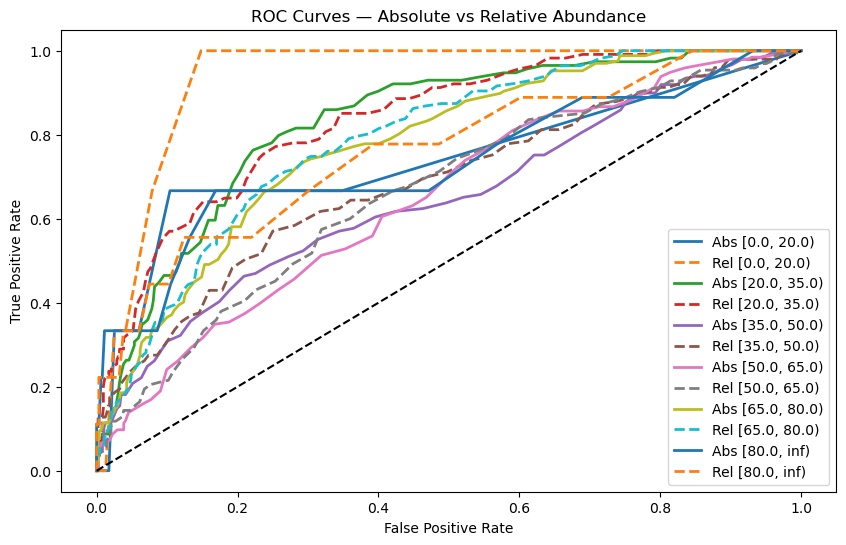

In [12]:
# Convert string labels to categorical codes for ROC/AUC
abs_test_codes = abs_Y_class_test.astype("category").cat.codes
rel_test_codes = rel_Y_class_test.astype("category").cat.codes

# Get the number of classes
classes = range(len(abs_Y_class_test.astype("category").cat.categories))

# Binarize
abs_y_test_bin = label_binarize(abs_test_codes, classes=classes)
rel_y_test_bin = label_binarize(rel_test_codes, classes=classes)

# Predicted probabilities
abs_y_prob = abs_rf.predict_proba(abs_X_test_log)
rel_y_prob = rel_rf.predict_proba(rel_X_test_log)

# Compute macro-AUC
auc_abs = roc_auc_score(abs_y_test_bin, abs_y_prob, average="macro")
auc_rel = roc_auc_score(rel_y_test_bin, rel_y_prob, average="macro")
print("Absolute Macro-AUC:", auc_abs)
print("Relative Macro-AUC:", auc_rel)

# Plot ROC curves
plt.figure(figsize=(10,6))

bin_labels = abs_Y_class_test.astype("category").cat.categories

for i in classes:
    fpr_abs, tpr_abs, _ = roc_curve(abs_y_test_bin[:, i], abs_y_prob[:, i])
    fpr_rel, tpr_rel, _ = roc_curve(rel_y_test_bin[:, i], rel_y_prob[:, i])
    plt.plot(fpr_abs, tpr_abs, lw=2, label=f"Abs {bin_labels[i]}")
    plt.plot(fpr_rel, tpr_rel, lw=2, linestyle='--', label=f"Rel {bin_labels[i]}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Absolute vs Relative Abundance")
plt.legend(loc="lower right")
plt.show()

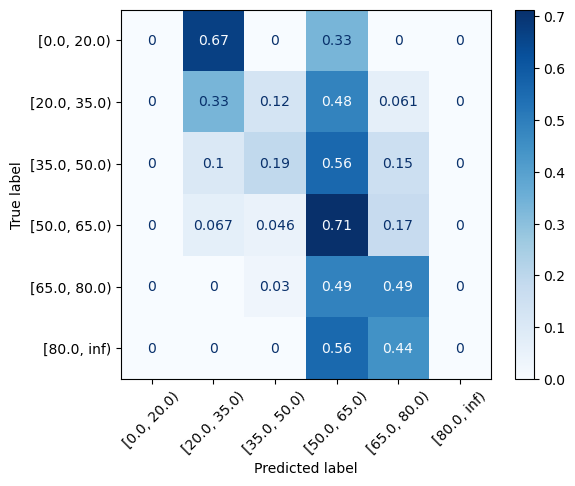

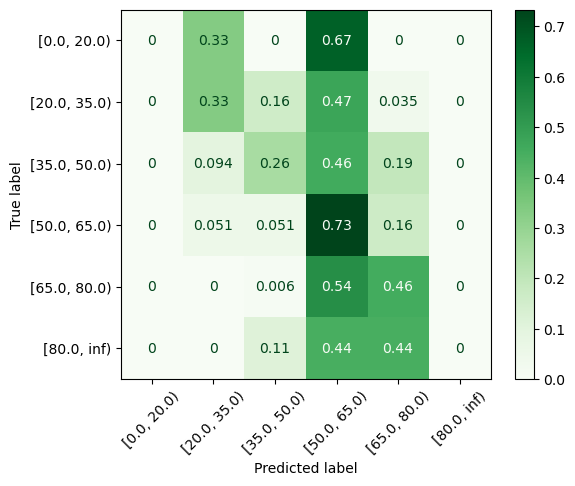

In [13]:
# Absolute abundance
disp_abs = ConfusionMatrixDisplay.from_predictions(
    abs_Y_class_test, 
    y_abs_pred, 
    normalize='true',
    cmap='Blues'
)
plt.xticks(rotation=45)  # rotate x-axis labels
plt.show()

# Relative abundance
disp_rel = ConfusionMatrixDisplay.from_predictions(
    rel_Y_class_test, 
    y_rel_pred, 
    normalize='true',
    cmap='Greens'
)
plt.xticks(rotation=45)  # rotate x-axis labels
plt.show()

In [14]:
# Checking if results are due to chance via bootstrapping
n_boot = 1000

acc_diffs = []
auc_diffs = []

abs_test_codes = abs_Y_class_test.astype("category").cat.codes
rel_test_codes = rel_Y_class_test.astype("category").cat.codes
classes = range(len(abs_Y_class_test.astype("category").cat.categories))

abs_y_test_bin = label_binarize(abs_test_codes, classes=classes)
rel_y_test_bin = label_binarize(rel_test_codes, classes=classes)

abs_y_prob = abs_rf.predict_proba(abs_X_test_log)
rel_y_prob = rel_rf.predict_proba(rel_X_test_log)

y_abs_pred = abs_rf.predict(abs_X_test_log)
y_rel_pred = rel_rf.predict(rel_X_test_log)

# Stratified bootstrap helper function
# Makes sure each sample has amounts from each class
def stratified_bootstrap_indices(y):
    indices = []
    for c in np.unique(y):
        class_indices = np.where(y == c)[0]
        resampled = resample(class_indices, replace=True, n_samples=len(class_indices))
        indices.extend(resampled)
    return np.array(indices)

# Bootstrap loop
for i in range(n_boot):
    indices = stratified_bootstrap_indices(abs_test_codes)

    # Calculate accuracy
    acc_abs_i = accuracy_score(abs_Y_class_test.iloc[indices], y_abs_pred[indices])
    acc_rel_i = accuracy_score(rel_Y_class_test.iloc[indices], y_rel_pred[indices])
    acc_diffs.append(acc_abs_i - acc_rel_i)

    # Calculate macro-AUC
    auc_abs_i = roc_auc_score(abs_y_test_bin[indices], abs_y_prob[indices], average='macro')
    auc_rel_i = roc_auc_score(rel_y_test_bin[indices], rel_y_prob[indices], average='macro')
    auc_diffs.append(auc_abs_i - auc_rel_i)

# Compute 95% confidence intervals
acc_ci = np.percentile(acc_diffs, [2.5, 97.5])
auc_ci = np.percentile(auc_diffs, [2.5, 97.5])

print("Accuracy difference 95% CI (Abs - Rel):", acc_ci)
print("Macro-AUC difference 95% CI (Abs - Rel):", auc_ci)

# Interpretation
if acc_ci[0] > 0 or acc_ci[1] < 0:
    print("Accuracy difference is statistically significant.")
else:
    print("Accuracy difference is NOT statistically significant.")

if auc_ci[0] > 0 or auc_ci[1] < 0:
    print("AUC difference is statistically significant.")
else:
    print("AUC difference is NOT statistically significant!")

Accuracy difference 95% CI (Abs - Rel): [-0.04870487  0.02197802]
Macro-AUC difference 95% CI (Abs - Rel): [-0.10882578 -0.00686985]
Accuracy difference is NOT statistically significant.
AUC difference is statistically significant.


In [22]:
# Top 20 feature names
abs_top20 = set(abs_feat_importance["feature"].head(20))
rel_top20 = set(rel_feat_importance["feature"].head(20))

print("Absolute Top 20:", abs_top20)
print("Relative Top 20:", rel_top20)

overlap = abs_top20.intersection(rel_top20)
print("Overlap:", overlap)
print("Number overlapping:", len(overlap))

Absolute Top 20: {'G000144735', 'G012357415', 'G000980515', 'G000188175', 'G000230275', 'G001405015', 'G001042635', 'G000431955', 'G000007525', 'G900539925', 'G900539845', 'G001578645', 'G000020225', 'G000436395', 'G001580195', 'G001701045', 'G000435455', 'G000259485', 'G000145555', 'G000238615'}
Relative Top 20: {'G900604345', 'G000299455', 'G001405615', 'G000438035', 'G000010425', 'G000230275', 'G001405015', 'G000437075', 'G000431955', 'G000160535', 'G902363055', 'G000398925', 'G900066445', 'G900066655', 'G000436395', 'G000381005', 'G001701045', 'G001808555', 'G000384195', 'G000832075'}
Overlap: {'G000230275', 'G001405015', 'G000431955', 'G000436395', 'G001701045'}
Number overlapping: 5


In [23]:
print("Unique to Absolute:", abs_top20 - rel_top20)
print("Unique to Relative:", rel_top20 - abs_top20)

Unique to Absolute: {'G000144735', 'G000007525', 'G000259485', 'G000145555', 'G000188175', 'G900539925', 'G000238615', 'G000435455', 'G012357415', 'G000980515', 'G900539845', 'G001578645', 'G001042635', 'G000020225', 'G001580195'}
Unique to Relative: {'G000438035', 'G900604345', 'G000010425', 'G000384195', 'G900066655', 'G000299455', 'G000398925', 'G001405615', 'G000381005', 'G000832075', 'G900066445', 'G000437075', 'G000160535', 'G902363055', 'G001808555'}


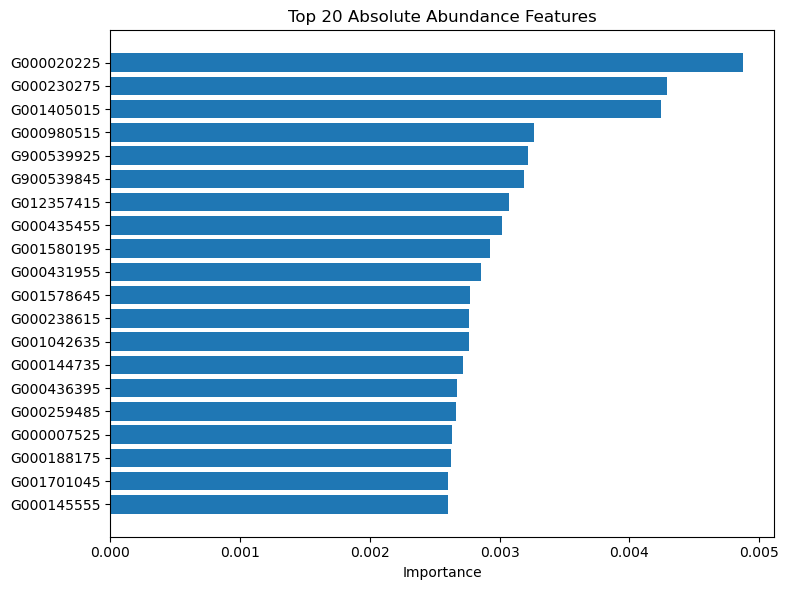

In [17]:
top_n = 20

plt.figure(figsize=(8,6))
plt.barh(
    abs_feat_importance["feature"][:top_n][::-1],
    abs_feat_importance["importance"][:top_n][::-1]
)
plt.title("Top 20 Absolute Abundance Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

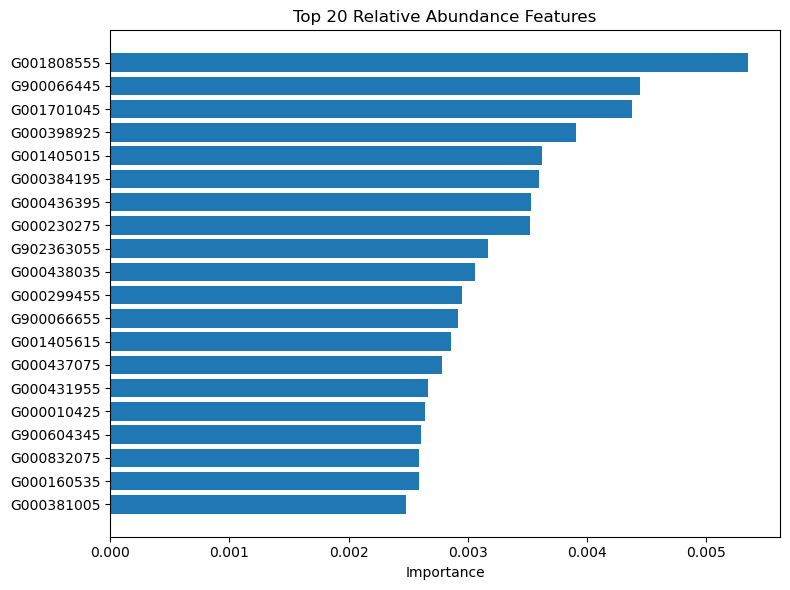

In [18]:
top_n = 20

plt.figure(figsize=(8,6))
plt.barh(
    rel_feat_importance["feature"][:top_n][::-1],
    rel_feat_importance["importance"][:top_n][::-1]
)
plt.title("Top 20 Relative Abundance Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Try clustering users with similar gene counts
# Try PCA to drop certain genes (making sure to document each one that gets dropped)
# Lasso regression
# Try using Wilson-Cox/correlation measures (ANOVA?) to see which genes have the most impact

In [36]:
val_preds = rf_reg.predict(X_val)

mae = mean_absolute_error(Y_val, val_preds)
rmse = mean_squared_error(Y_val, val_preds, squared=False)
r2 = r2_score(Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 10.897269900497513
RMSE (years): 12.588626268943631
R²: 0.2286294265398271


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [37]:
bins = train['age_bin'].cat.categories

val_preds_bins = pd.cut(
    val_preds,
    bins=[b.left for b in bins] + [bins[-1].right],
    right=False
)

accuracy_score(Y_val.astype(str), val_preds_bins.astype(str))

0.0

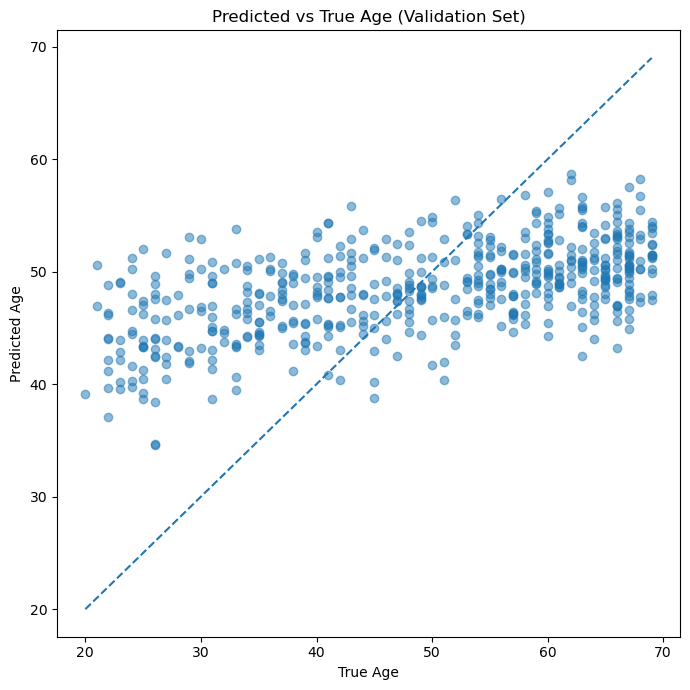

In [38]:
plt.figure(figsize=(7, 7))
plt.scatter(Y_val, val_preds, alpha=0.5)

# Perfect prediction line
min_age = min(Y_val.min(), val_preds.min())
max_age = max(Y_val.max(), val_preds.max())
plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs True Age (Validation Set)")
plt.tight_layout()
plt.show()

In [ ]:
# Trying the methodology from this paper: https://journals.asm.org/doi/10.1128/msystems.00630-19


In [50]:
import numpy as np
from scipy.interpolate import UnivariateSpline

# Sort by age (required for spline stability)
order = np.argsort(Y_val)
x = np.array(Y_val)[order]
y = np.array(val_preds)[order]

# Fit smoothing spline
spline = UnivariateSpline(
    x,
    y,
    s=len(x) * np.var(y)
)

In [51]:
# Expected microbiota age from spline
expected_microbiota_age = spline(Y_val)

# Relative microbiota age
relative_microbiota_age = val_preds - expected_microbiota_age

In [53]:
val["microbiota_age"] = val_preds
val["expected_microbiota_age"] = expected_microbiota_age
val["relative_microbiota_age"] = relative_microbiota_age

In [54]:
val.head()

,original_SampleID,G000006865,G000006925,G000007265,G000007325,G000007465,G000007525,G000007645,G000007785,G000008345,...,qiita_study_alias,qiita_owner,qiita_principal_investigator,extracted_gdna_concentration_ng_ul,mass_syndna_input_ng,syndna_pool_number,age_bin,microbiota_age,expected_microbiota_age,relative_microbiota_age
0,15288.MMC.24900843682.364366053,5869.844051,9675.663254,26869.325389,1693.246282,20775.100707,8.621772e+06,0.0,8613.686009,3797.046086,...,NPH,MacKenzie Bryant,Rob Knight,5.860,0.249912,1,"[50, 60)",45.973333,49.109082,-3.135748
1,15288.MMC.24901046909.364416064,0.000000,9923.882099,970.760637,0.000000,0.000000,1.449637e+05,0.0,3352.268533,0.000000,...,NPH,MacKenzie Bryant,Rob Knight,4.744,0.250120,1,"[40, 50)",51.686667,47.981313,3.705353
2,15288.MMC.24900843414.363385531,725.534407,3220.829406,297.236508,0.000000,0.000000,4.389260e+02,0.0,2626.573813,0.000000,...,NPH,MacKenzie Bryant,Rob Knight,2.674,0.250019,1,"[40, 50)",49.526667,47.826619,1.700048
3,15288.MMC.23900725897.364379869,19109.751919,68642.493172,1208.013009,0.000000,0.000000,2.411458e+05,0.0,20516.647319,0.000000,...,NPH,MacKenzie Bryant,Rob Knight,21.043,0.249843,1,"[30, 40)",51.636667,47.339975,4.296692
4,15288.MMC.24900933592.363398066,24032.074786,1978.868653,1606.019938,118.478549,126.729517,6.982199e+06,0.0,12046.049220,213.374905,...,NPH,MacKenzie Bryant,Rob Knight,1.829,0.250001,1,"[20, 30)",46.593333,44.247244,2.346089


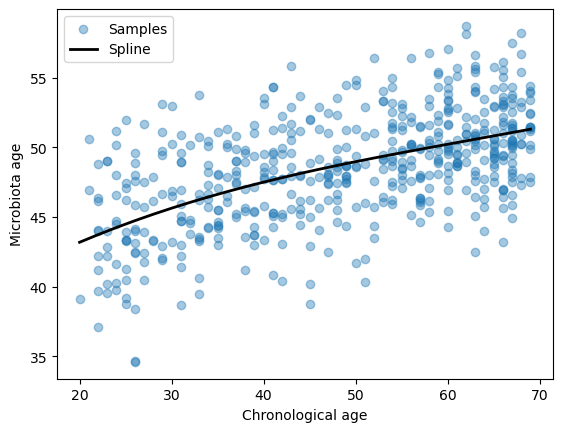

In [56]:
import matplotlib.pyplot as plt

plt.scatter(Y_val, val_preds, alpha=0.4, label="Samples")
plt.plot(x, spline(x), color="black", linewidth=2, label="Spline")
plt.xlabel("Chronological age")
plt.ylabel("Microbiota age")
plt.legend()
plt.show()

In [61]:
# Comparison with relative abundance
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv')
rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv')

# Using American Gut Microbiome Project age cutoffs
rel_train = rel_train.loc[(rel_train["age"] >= 20) & (train["age"] <= 69)]
rel_test = rel_test.loc[(rel_test["age"] >= 20) & (rel_test["age"] <= 69)]
rel_val = rel_val.loc[(rel_val["age"] >= 20) & (rel_val["age"] <= 69)]

rel_X_train = rel_train[rel_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val   = rel_val['age']

/tmp/ipykernel_5352/1556685501.py:3: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')


In [62]:
rel_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_reg.fit(rel_X_train, rel_Y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [68]:
val_preds = rel_rf_reg.predict(rel_X_val)

mae = mean_absolute_error(rel_Y_val, val_preds)
rmse = mean_squared_error(rel_Y_val, val_preds, squared=False)
r2 = r2_score(rel_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 10.317615433270081
RMSE (years): 11.92248853951684
R²: 0.24973113478826847


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


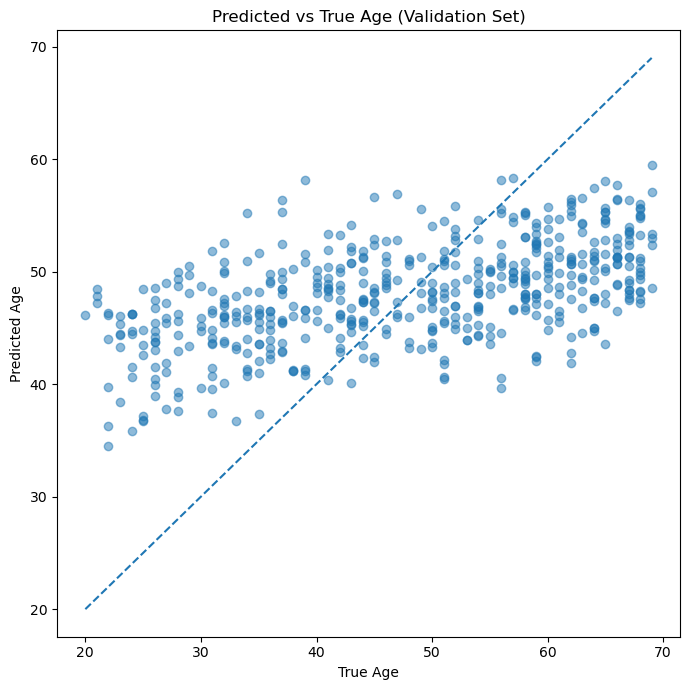

In [69]:
plt.figure(figsize=(7, 7))
plt.scatter(rel_Y_val, val_preds, alpha=0.5)

# Perfect prediction line
min_age = min(Y_val.min(), val_preds.min())
max_age = max(Y_val.max(), val_preds.max())
plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs True Age (Validation Set)")
plt.tight_layout()
plt.show()

In [70]:
# Sort by age (required for spline stability)
order = np.argsort(rel_Y_val)
x = np.array(rel_Y_val)[order]
y = np.array(val_preds)[order]

# Fit smoothing spline
spline = UnivariateSpline(
    x,
    y,
    s=len(x) * np.var(y)
)

In [72]:
# Expected microbiota age from spline
expected_microbiota_age = spline(rel_Y_val)

# Relative microbiota age
relative_microbiota_age = val_preds - expected_microbiota_age

In [73]:
rel_val["microbiota_age"] = val_preds
rel_val["expected_microbiota_age"] = expected_microbiota_age
rel_val["relative_microbiota_age"] = relative_microbiota_age

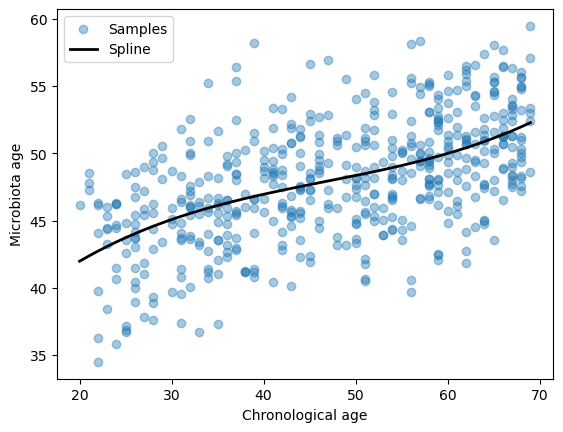

In [74]:
plt.scatter(rel_Y_val, val_preds, alpha=0.4, label="Samples")
plt.plot(x, spline(x), color="black", linewidth=2, label="Spline")
plt.xlabel("Chronological age")
plt.ylabel("Microbiota age")
plt.legend()
plt.show()